In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 2000)        # use very wide width
pd.set_option("display.max_columns", None)  # show all columns
pd.set_option("display.max_colwidth", None) # do not truncate text
pd.set_option("display.expand_frame_repr", False)  # no wrapping

In [2]:

df = pd.read_parquet("data/processed/cfr_savings_processed.parquet")
print(f"Rows: {len(df)} | Columns: {len(df.columns)}")
print(df.columns.tolist())

Rows: 13194 | Columns: 122
['case_number', 'case_priority', 'case_type', 'subject', 'creation_date', 'disposition_date', 'teco_date', 'market', 'country', 'ib_service_team', 'remote_remarks', 'field_remarks', 'remote_remarks_en', 'field_remarks_en', 'equipment', 'system_code', 'parts_consumed_list', 'remote_hours', 'travel_hours', 'onsite_hours', 'offsite_hours', 'total_hours', 'ttsu_days', 'ttsu_bucket', 'diagnostic_text', 'diagnostic_date', 'follow_up_text', 'follow_up_date', 'problem_description_text', 'problem_description_date', 'resolution_text', 'resolution_date', 'internal_comments_text', 'internal_comments_date', 'internal_remarks_text', 'internal_remarks_date', 'external_remarks_text', 'external_remarks_date', 'parent_diagnostic_text', 'parent_diagnostic_date', 'parent_follow_up_text', 'parent_follow_up_date', 'parent_problem_description_text', 'parent_problem_description_date', 'parent_resolution_text', 'parent_resolution_date', 'parent_internal_comments_text', 'parent_intern

In [3]:
print(df["diagnostic_text"].notna().sum())

3002


In [4]:
country_count = (
    df.groupby('country')
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
)

C:\Users\320305732\AppData\Local\Temp\ipykernel_3752\3382592043.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", min(TOP_N, 20))


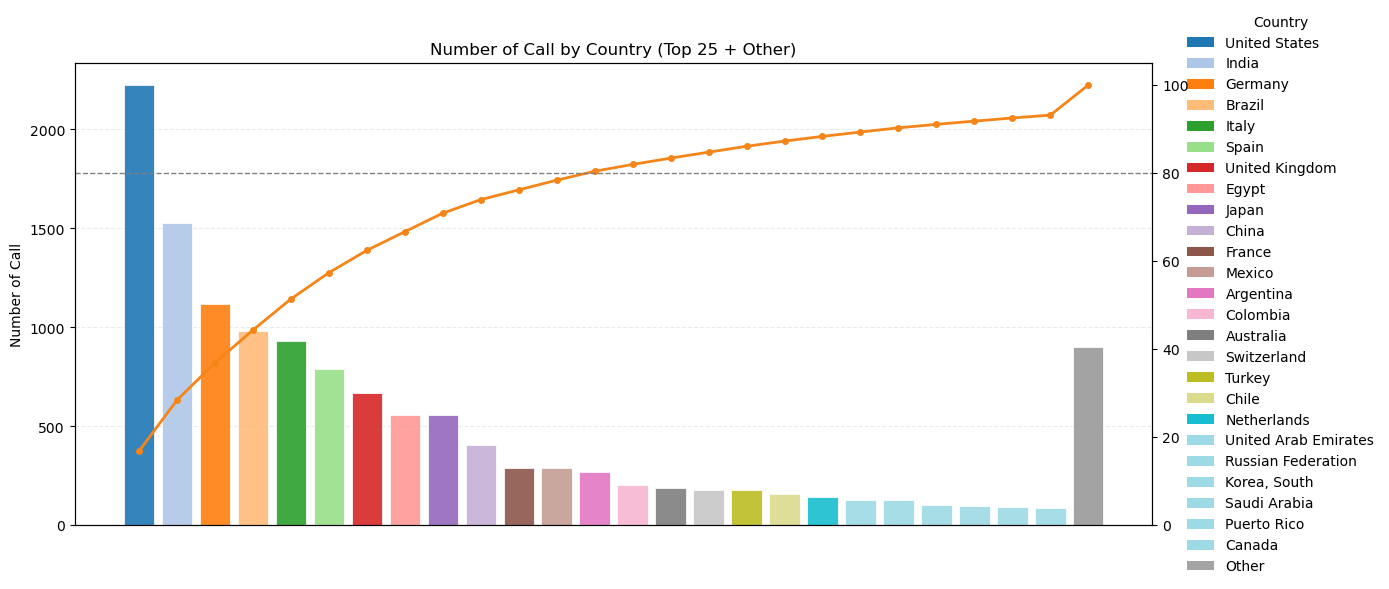

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

TOP_N = 25

# --- Build Top N + Other ---
cc = country_count.copy()
cc["country"] = cc["country"].astype(str)
cc["count"] = cc["count"].astype(float)

top = cc.head(TOP_N).copy()
other = cc["count"].iloc[TOP_N:].sum()

if other > 0:
    plot_df = pd.concat(
        [top, pd.DataFrame([{"country": "Other", "count": other}])],
        ignore_index=True
    )
else:
    plot_df = top.copy()

plot_df["cum_pct"] = plot_df["count"].cumsum() / plot_df["count"].sum() * 100

# --- Colors (Top 20 + gray for Other) ---
cmap = plt.cm.get_cmap("tab20", min(TOP_N, 20))
colors = [cmap(i) for i in range(len(plot_df))]
if plot_df["country"].iloc[-1] == "Other":
    colors[-1] = (0.6, 0.6, 0.6, 0.9)

# --- Plot ---
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x, plot_df["count"], color=colors, alpha=0.9, edgecolor="white", linewidth=0.6)
ax.set_ylabel("Number of Call")
ax.set_title(f"Number of Call by Country (Top {TOP_N} + Other)")
ax.yaxis.grid(True, linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

# Remove x-axis tick labels (legend will be used instead)
ax.set_xticks([])
ax.set_xlabel("")  # no label under bars

# Pareto line (secondary axis)
ax2 = ax.twinx()
ax2.plot(x, plot_df["cum_pct"], color="#F58518", marker="o", linewidth=2, markersize=4)
#ax2.set_ylabel("Cumulative %")
ax2.set_ylim(0, 105)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)

# Legend on the right (one entry per bar)
handles = [Patch(facecolor=colors[i], edgecolor="none") for i in range(len(plot_df))]
labels = plot_df["country"].tolist()

ax.legend(
    handles, labels,
    title="Country",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()

# Missing values

## Call Missing Values

In [6]:
n = len(df)

field_missing = df["field_remarks"].isna().sum()
remote_missing = df["remote_remarks"].isna().sum()

field_missing_pct = round(field_missing / n * 100, 1)
remote_missing_pct = round(remote_missing / n * 100, 1)

print(f"Total rows: {n}")
print(f"field_remarks missing (NaN):  {field_missing} ({field_missing_pct}%)")
print(f"remote_remarks missing (NaN): {remote_missing} ({remote_missing_pct}%)")

Total rows: 13194
field_remarks missing (NaN):  5596 (42.4%)
remote_remarks missing (NaN): 905 (6.9%)


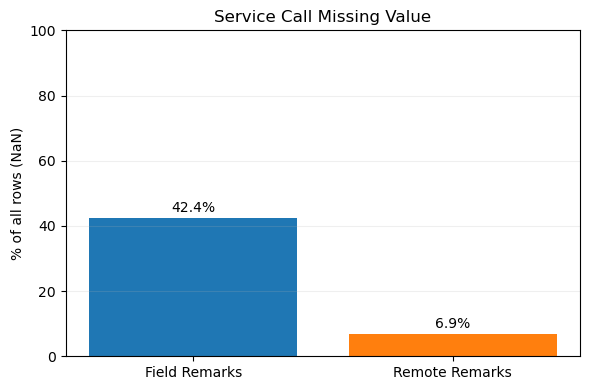

In [7]:
import matplotlib.pyplot as plt

labels = ["Field Remarks", "Remote Remarks"]
pcts = [field_missing_pct, remote_missing_pct]
colors = ["tab:blue", "tab:orange"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, pcts, color=colors)

ax.set_title("Service Call Missing Value")
ax.set_ylabel("% of all rows (NaN)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.2)

for i, v in enumerate(pcts):
    ax.text(i, v + 1, f"{v}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

Missing values by country

In [8]:
import pandas as pd
import numpy as np

missing_by_country = df.groupby("country").agg(
    n_rows=("country", "size"),
    field_missing=("field_remarks", lambda s: s.isna().sum()),
    remote_missing=("remote_remarks", lambda s: s.isna().sum()),
).reset_index()

missing_by_country["field_missing_pct"] = (missing_by_country["field_missing"] / missing_by_country["n_rows"] * 100).round(1)
missing_by_country["remote_missing_pct"] = (missing_by_country["remote_missing"] / missing_by_country["n_rows"] * 100).round(1)

# (optional) sort by volume descending
missing_by_country = missing_by_country.sort_values("n_rows", ascending=False).reset_index(drop=True)

missing_by_country

,country,n_rows,field_missing,remote_missing,field_missing_pct,remote_missing_pct
0,United States,2224,833,254,37.5,11.4
1,India,1526,415,0,27.2,0.0
2,Germany,1119,455,64,40.7,5.7
3,Brazil,981,914,102,93.2,10.4
4,Italy,931,387,23,41.6,2.5
5,Spain,788,391,47,49.6,6.0
6,United Kingdom,670,291,60,43.4,9.0
7,Egypt,559,362,9,64.8,1.6
8,Japan,555,4,0,0.7,0.0
9,China,406,38,18,9.4,4.4


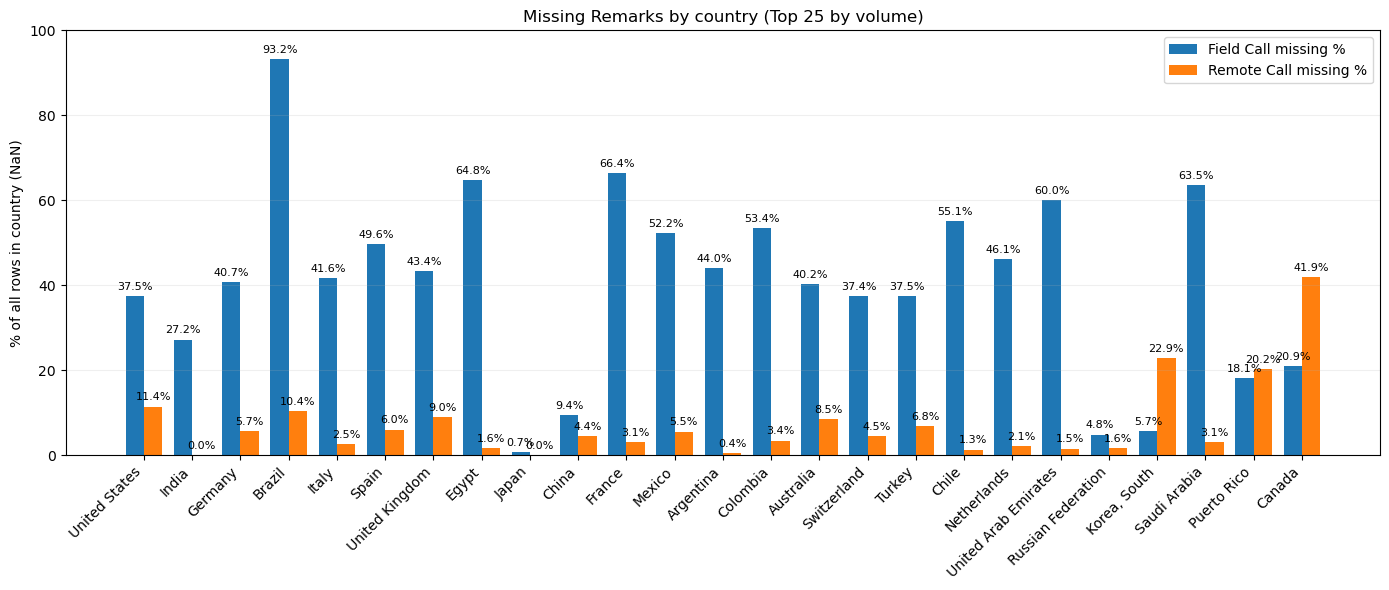

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# assumes you already created `missing_by_country` from the previous snippet
top_n = 25
top25 = missing_by_country.sort_values("n_rows", ascending=False).head(top_n).copy()

x = np.arange(len(top25))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 6))

# blue = field, orange = remote
ax.bar(x - w/2, top25["field_missing_pct"], width=w, color="tab:blue", label="Field Call missing %")
ax.bar(x + w/2, top25["remote_missing_pct"], width=w, color="tab:orange", label="Remote Call missing %")

ax.set_title("Missing Remarks by country (Top 25 by volume)")
ax.set_ylabel("% of all rows in country (NaN)")
ax.set_xticks(x)
ax.set_xticklabels(top25["country"], rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.2)

# optional: annotate bars
for i, (fv, rv) in enumerate(zip(top25["field_missing_pct"], top25["remote_missing_pct"])):
    ax.text(i - w/2, fv + 1, f"{fv:.1f}%", ha="center", va="bottom", fontsize=8)
    ax.text(i + w/2, rv + 1, f"{rv:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## Part Consumed 

In [10]:
n = len(df)

parts_non_missing = df["parts_consumed_list"].notna().sum()
parts_non_missing_pct = round(parts_non_missing / n * 100, 1)

print(f"Total rows: {n}")
print(f"parts_consumed_list not-NaN: {parts_non_missing} ({parts_non_missing_pct}%)")

Total rows: 13194
parts_consumed_list not-NaN: 4567 (34.6%)


C:\Users\320305732\AppData\Local\Temp\ipykernel_3752\1524698444.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm.get_cmap("viridis")(0.7),  # green-ish
C:\Users\320305732\AppData\Local\Temp\ipykernel_3752\1524698444.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm.get_cmap("viridis")(0.3),  # blue/purple


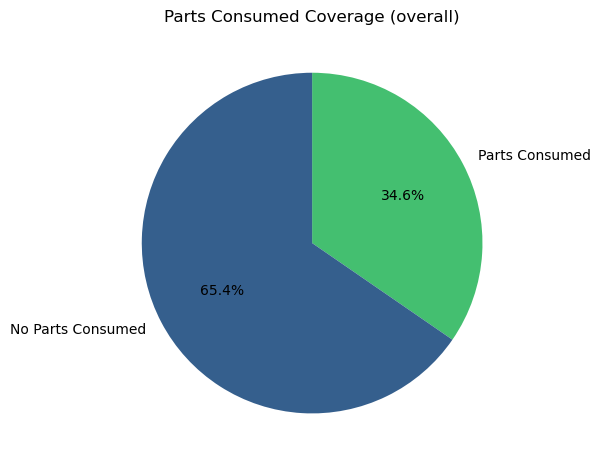

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# percentages
sizes = [
    parts_non_missing_pct,
    100 - parts_non_missing_pct
]

labels = [
    "Parts Consumed",
    "No Parts Consumed"
]

# viridis palette
colors = [
    cm.get_cmap("viridis")(0.7),  # green-ish
    cm.get_cmap("viridis")(0.3),  # blue/purple
]

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)

ax.set_title("Parts Consumed Coverage (overall)")

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

parts_by_country = df.groupby("country").agg(
    n_rows=("country", "size"),
    parts_non_missing=("parts_consumed_list", lambda s: s.notna().sum()),
).reset_index()

parts_by_country["parts_non_missing_pct"] = (
    parts_by_country["parts_non_missing"] / parts_by_country["n_rows"] * 100
).round(1)

# optional: sort by volume (descending)
parts_by_country = parts_by_country.sort_values("n_rows", ascending=False).reset_index(drop=True)

#parts_by_country

C:\Users\320305732\AppData\Local\Temp\ipykernel_3752\819829395.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  green = cm.get_cmap("viridis")(0.7)


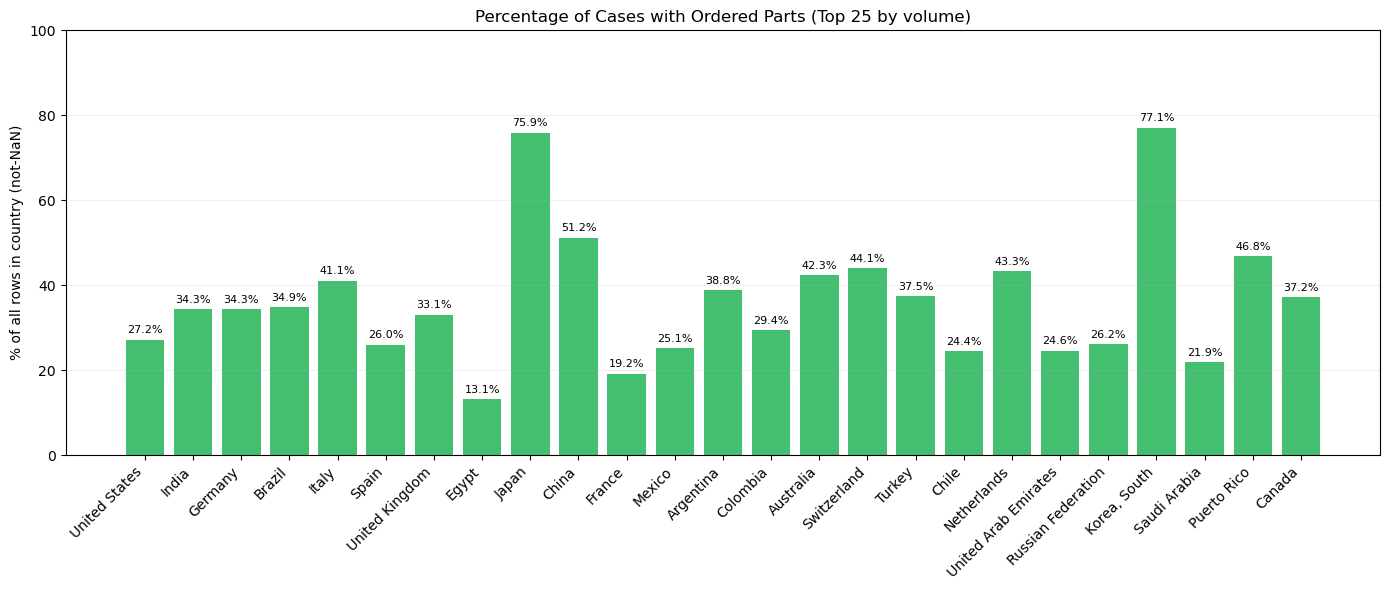

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

green = cm.get_cmap("viridis")(0.7)

top_n = 25
top25 = parts_by_country.sort_values("n_rows", ascending=False).head(top_n).copy()

x = np.arange(len(top25))

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x, top25["parts_non_missing_pct"], color=green)

ax.set_title("Percentage of Cases with Ordered Parts (Top 25 by volume)")
ax.set_ylabel("% of all rows in country (not-NaN)")
ax.set_xticks(x)
ax.set_xticklabels(top25["country"], rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.2)

# optional annotations
for i, v in enumerate(top25["parts_non_missing_pct"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## Extraction percentage

In [14]:
df_nam = df[df["market"] == "NAM"]

In [15]:
print(df_nam.head(15))

     case_number  case_priority case_type                                                                          subject creation_date disposition_date  teco_date market        country ib_service_team                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [16]:
key_cols = [
    "extracted_problem_description_field",
    "extracted_error_field",
    "extracted_malfunction_area_field",
    "extracted_troubleshooting_field",
    "extracted_repair_action_field",
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
    "extracted_diagnostic_remote", 
    "extracted_diagnostic_field"
]

for col in key_cols:
    filled = df_nam[col].notna().sum()
    pct = round(filled / len(df_nam) * 100, 1)
    print(f"{col}: {filled} ({pct}%)")

extracted_problem_description_field: 1143 (49.5%)
extracted_error_field: 0 (0.0%)
extracted_malfunction_area_field: 305 (13.2%)
extracted_troubleshooting_field: 0 (0.0%)
extracted_repair_action_field: 1338 (57.9%)
extracted_problem_description_remote: 1803 (78.1%)
extracted_error_remote: 507 (21.9%)
extracted_malfunction_area_remote: 533 (23.1%)
extracted_troubleshooting_remote: 0 (0.0%)
extracted_repair_action_remote: 1785 (77.3%)
extracted_diagnostic_remote: 1742 (75.4%)
extracted_diagnostic_field: 640 (27.7%)


In [17]:
key_cols = [
    "extracted_problem_description_field",
    "extracted_error_field",
    "extracted_malfunction_area_field",
    "extracted_troubleshooting_field",
    "extracted_repair_action_field",
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
    "extracted_diagnostic_remote", 
    "extracted_diagnostic_field"
]

for col in key_cols:
    filled = df[col].notna().sum()
    pct = round(filled / len(df) * 100, 1)
    print(f"{col}: {filled} ({pct}%)")

extracted_problem_description_field: 5861 (44.4%)
extracted_error_field: 12 (0.1%)
extracted_malfunction_area_field: 2961 (22.4%)
extracted_troubleshooting_field: 27 (0.2%)
extracted_repair_action_field: 6593 (50.0%)
extracted_problem_description_remote: 11402 (86.4%)
extracted_error_remote: 3993 (30.3%)
extracted_malfunction_area_remote: 5732 (43.4%)
extracted_troubleshooting_remote: 1365 (10.3%)
extracted_repair_action_remote: 10108 (76.6%)
extracted_diagnostic_remote: 9901 (75.0%)
extracted_diagnostic_field: 2679 (20.3%)


extracted problem description

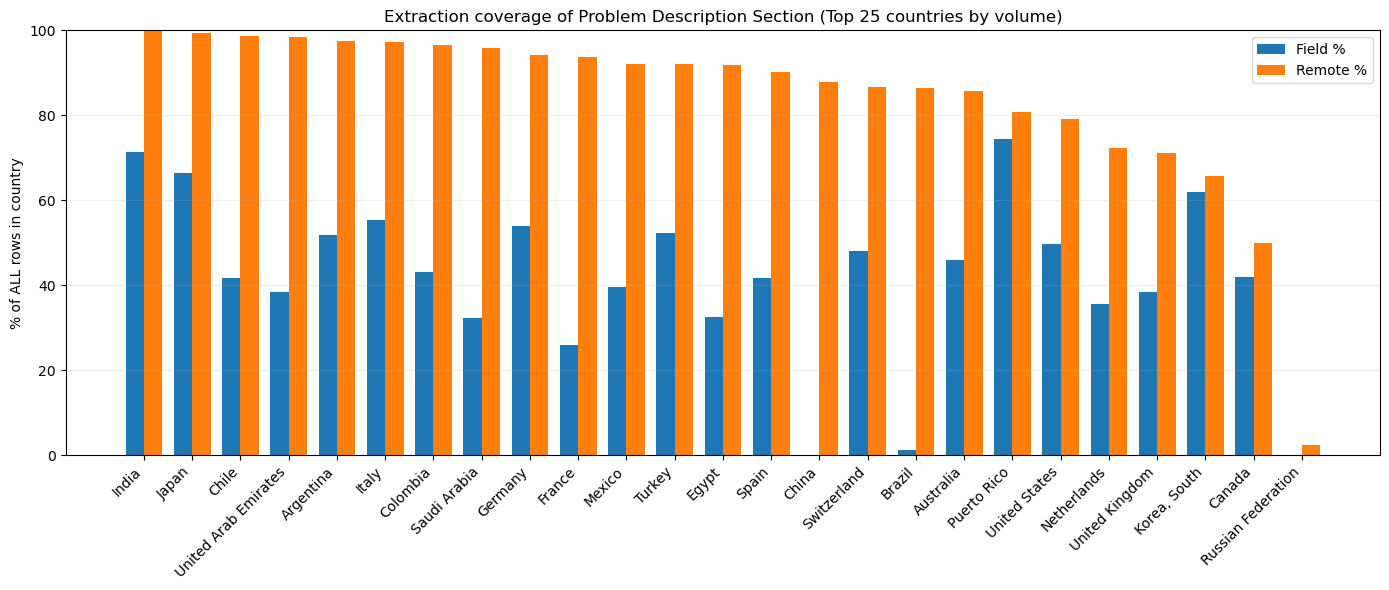

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- settings ---
top_n = 25
country_col = "country"
field_col = "extracted_problem_description_field"
remote_col = "extracted_problem_description_remote"

# --- top countries by volume ---
top_countries = df[country_col].value_counts().head(top_n).index
dft = df[df[country_col].isin(top_countries)].copy()

# keep order = descending volume
order = dft[country_col].value_counts().loc[top_countries].index.tolist()

# --- compute % over ALL rows per country ---
grp = dft.groupby(country_col)
summary = pd.DataFrame({
    "country": order,
    "n_rows": grp.size().reindex(order).values,
    "field_pct": (grp[field_col].apply(lambda s: s.notna().mean()) * 100).reindex(order).values,
    "remote_pct": (grp[remote_col].apply(lambda s: s.notna().mean()) * 100).reindex(order).values,
})

summary = summary.sort_values("remote_pct", ascending=False).reset_index(drop=True)

# --- plot ---
x = np.arange(len(summary))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, summary["field_pct"], width=w, label="Field %")
ax.bar(x + w/2, summary["remote_pct"], width=w, label="Remote %")

ax.set_title("Extraction coverage of Problem Description Section (Top 25 countries by volume)")
ax.set_ylabel("% of ALL rows in country")
ax.set_xticks(x)
ax.set_xticklabels(summary["country"], rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

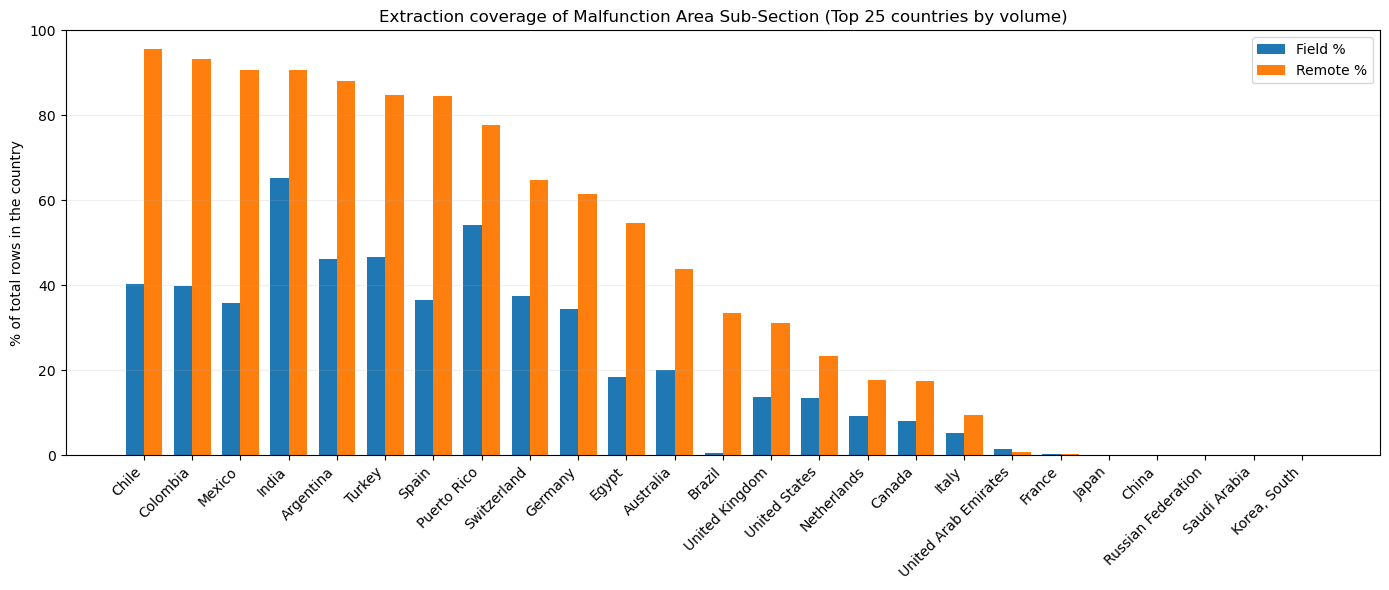

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- settings ---
top_n = 25
country_col = "country"
field_col = "extracted_malfunction_area_field"
remote_col = "extracted_malfunction_area_remote"

# --- top countries by volume ---
top_countries = df[country_col].value_counts().head(top_n).index
dft = df[df[country_col].isin(top_countries)].copy()

# keep order = descending volume
order = dft[country_col].value_counts().loc[top_countries].index.tolist()

# --- compute % over ALL rows per country ---
grp = dft.groupby(country_col)
summary = pd.DataFrame({
    "country": order,
    "n_rows": grp.size().reindex(order).values,
    "field_pct": (grp[field_col].apply(lambda s: s.notna().mean()) * 100).reindex(order).values,
    "remote_pct": (grp[remote_col].apply(lambda s: s.notna().mean()) * 100).reindex(order).values,
})

summary = summary.sort_values("remote_pct", ascending=False).reset_index(drop=True)

# --- plot ---
x = np.arange(len(summary))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, summary["field_pct"], width=w, label="Field %")
ax.bar(x + w/2, summary["remote_pct"], width=w, label="Remote %")

ax.set_title("Extraction coverage of Malfunction Area Sub-Section (Top 25 countries by volume)")
ax.set_ylabel("% of total rows in the country")
ax.set_xticks(x)
ax.set_xticklabels(summary["country"], rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

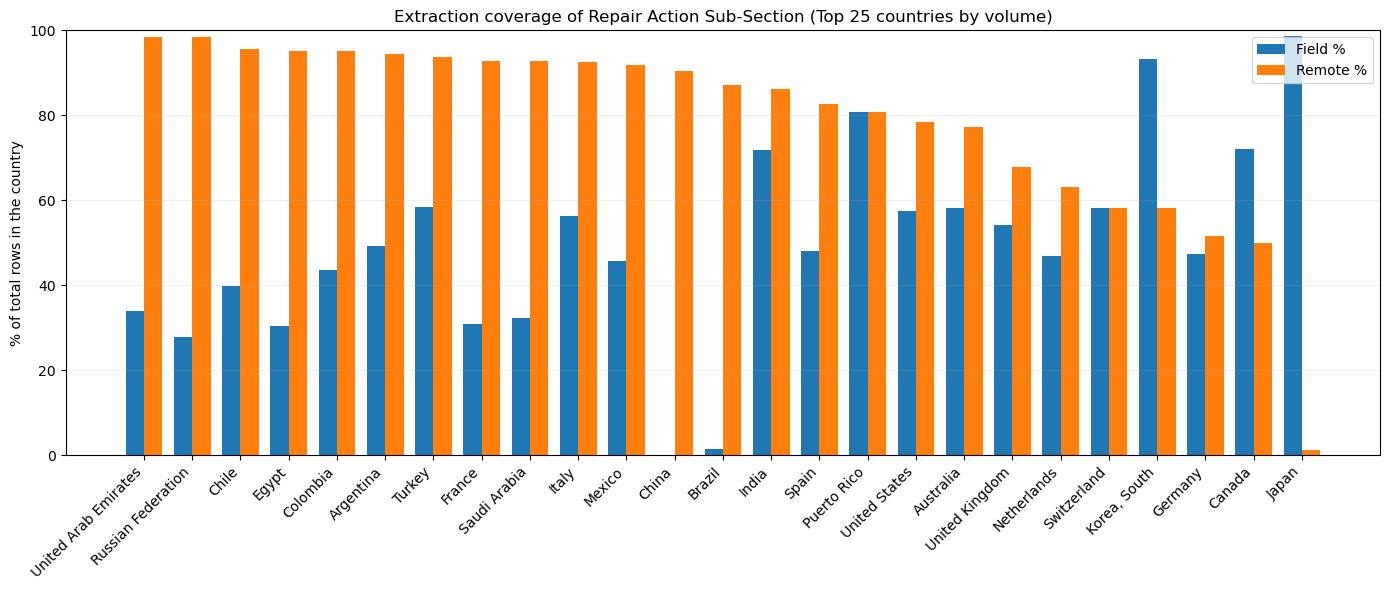

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- settings ---
top_n = 25
country_col = "country"
field_col = "extracted_repair_action_field"
remote_col = "extracted_repair_action_remote"

# --- top countries by volume ---
top_countries = df[country_col].value_counts().head(top_n).index
dft = df[df[country_col].isin(top_countries)].copy()

# keep order = descending volume
order = dft[country_col].value_counts().loc[top_countries].index.tolist()

# --- compute % over ALL rows per country ---
grp = dft.groupby(country_col)
summary = pd.DataFrame({
    "country": order,
    "n_rows": grp.size().reindex(order).values,
    "field_pct": (grp[field_col].apply(lambda s: s.notna().mean()) * 100).reindex(order).values,
    "remote_pct": (grp[remote_col].apply(lambda s: s.notna().mean()) * 100).reindex(order).values,
})
summary = summary.sort_values("remote_pct", ascending=False).reset_index(drop=True)

# --- plot ---
x = np.arange(len(summary))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, summary["field_pct"], width=w, label="Field %")
ax.bar(x + w/2, summary["remote_pct"], width=w, label="Remote %")

ax.set_title("Extraction coverage of Repair Action Sub-Section (Top 25 countries by volume)")
ax.set_ylabel("% of total rows in the country")
ax.set_xticks(x)
ax.set_xticklabels(summary["country"], rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

#### by country

In [21]:
import pandas as pd
import numpy as np

field_cols = [
    "extracted_problem_description_field",
    "extracted_error_field",
    "extracted_malfunction_area_field",
    "extracted_troubleshooting_field",
    "extracted_repair_action_field", 
    "extracted_diagnostic_field",
]

remote_cols = [
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
    "extracted_diagnostic_remote",
]

rows = []

# Denominator per country = ALL rows in that country
country_den = df.groupby("country").size()  # total rows per country

# ---- FIELD block ----
for col in field_cols:
    extracted = df.groupby("country")[col].apply(lambda s: s.notna().sum())

    tmp = pd.DataFrame({
        "country": country_den.index,
        "scope": "field",
        "variable": col,
        "extracted_count": extracted.reindex(country_den.index).fillna(0).astype(int).values,
        "eligible_count": country_den.values.astype(int),  # <- now total rows in country
    })

    tmp["extraction_pct"] = np.where(
        tmp["eligible_count"] > 0,
        (tmp["extracted_count"] / tmp["eligible_count"] * 100).round(1),
        0.0
    )
    rows.append(tmp)

# ---- REMOTE block ----
for col in remote_cols:
    extracted = df.groupby("country")[col].apply(lambda s: s.notna().sum())

    tmp = pd.DataFrame({
        "country": country_den.index,
        "scope": "remote",
        "variable": col,
        "extracted_count": extracted.reindex(country_den.index).fillna(0).astype(int).values,
        "eligible_count": country_den.values.astype(int),
    })

    tmp["extraction_pct"] = np.where(
        tmp["eligible_count"] > 0,
        (tmp["extracted_count"] / tmp["eligible_count"] * 100).round(1),
        0.0
    )
    rows.append(tmp)

country_extraction_summary_allrows = (
    pd.concat(rows, ignore_index=True)
      .sort_values(["scope", "variable", "extraction_pct"], ascending=[True, True, False])
      .reset_index(drop=True)
)

country_extraction_summary_allrows

,country,scope,variable,extracted_count,eligible_count,extraction_pct
0,Bangladesh,field,extracted_diagnostic_field,7,11,63.6
1,Malaysia,field,extracted_diagnostic_field,4,8,50.0
2,Norway,field,extracted_diagnostic_field,19,43,44.2
3,Thailand,field,extracted_diagnostic_field,21,51,41.2
4,Kenya,field,extracted_diagnostic_field,2,5,40.0
...,...,...,...,...,...,...
631,Thailand,remote,extracted_troubleshooting_remote,0,51,0.0
632,United Arab Emirates,remote,extracted_troubleshooting_remote,0,130,0.0
633,United Kingdom,remote,extracted_troubleshooting_remote,0,670,0.0
634,United States,remote,extracted_troubleshooting_remote,0,2224,0.0


In [22]:
key_cols = field_cols + remote_cols

country_key_summary = (
    df.groupby("country")[key_cols]
      .apply(lambda g: g.notna().sum())
      .astype(int)
      .join(df.groupby("country").size().rename("total_rows"))
)

country_key_pct = (
    country_key_summary[key_cols]
    .div(country_key_summary["total_rows"], axis=0)
    .mul(100)
    .round(1)
)

# long format (handy for plots)
country_key_long = (
    country_key_summary[key_cols]
    .stack()
    .rename("filled")
    .reset_index()
    .rename(columns={"level_1": "variable"})
    .merge(country_key_summary["total_rows"].reset_index(), on="country", how="left")
)

country_key_long["pct"] = (country_key_long["filled"] / country_key_long["total_rows"] * 100).round(1)
country_key_long.sort_values(["variable", "pct"], ascending=[True, False]).reset_index(drop=True)

,country,variable,filled,total_rows,pct
0,Bangladesh,extracted_diagnostic_field,7,11,63.6
1,Malaysia,extracted_diagnostic_field,4,8,50.0
2,Norway,extracted_diagnostic_field,19,43,44.2
3,Thailand,extracted_diagnostic_field,21,51,41.2
4,Kenya,extracted_diagnostic_field,2,5,40.0
...,...,...,...,...,...
631,Thailand,extracted_troubleshooting_remote,0,51,0.0
632,United Arab Emirates,extracted_troubleshooting_remote,0,130,0.0
633,United Kingdom,extracted_troubleshooting_remote,0,670,0.0
634,United States,extracted_troubleshooting_remote,0,2224,0.0


### On non nana value

In [23]:
field_cols = [
    "extracted_problem_description_field",
    "extracted_error_field",
    "extracted_malfunction_area_field",
    "extracted_troubleshooting_field",
    "extracted_repair_action_field",
    "extracted_diagnostic_field",
]

remote_cols = [
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
    "extracted_diagnostic_remote",
]

# Denominators
field_den = df["field_remarks"].notna().sum()
remote_den = df["remote_remarks"].notna().sum()

# Field-based extraction %
for col in field_cols:
    extracted = df.loc[df["field_remarks"].notna(), col].notna().sum()
    pct = round(extracted / field_den * 100, 1) if field_den else 0.0
    print(f"{col}: {extracted} / {field_den} ({pct}%)")

# Remote-based extraction %
for col in remote_cols:
    extracted = df.loc[df["remote_remarks"].notna(), col].notna().sum()
    pct = round(extracted / remote_den * 100, 1) if remote_den else 0.0
    print(f"{col}: {extracted} / {remote_den} ({pct}%)")

extracted_problem_description_field: 5838 / 7598 (76.8%)
extracted_error_field: 12 / 7598 (0.2%)
extracted_malfunction_area_field: 2951 / 7598 (38.8%)
extracted_troubleshooting_field: 27 / 7598 (0.4%)
extracted_repair_action_field: 6569 / 7598 (86.5%)
extracted_diagnostic_field: 2668 / 7598 (35.1%)
extracted_problem_description_remote: 11375 / 12289 (92.6%)
extracted_error_remote: 3984 / 12289 (32.4%)
extracted_malfunction_area_remote: 5721 / 12289 (46.6%)
extracted_troubleshooting_remote: 1365 / 12289 (11.1%)
extracted_repair_action_remote: 10087 / 12289 (82.1%)
extracted_diagnostic_remote: 9874 / 12289 (80.3%)


In [24]:
field_cols = [
    "extracted_problem_description_field",
    "extracted_error_field",
    "extracted_malfunction_area_field",
    "extracted_troubleshooting_field",
    "extracted_repair_action_field",
    "extracted_diagnostic_field",
]

remote_cols = [
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
    "extracted_diagnostic_remote",
]

rows = []

# Denominators
field_den = df["field_remarks"].notna().sum()
remote_den = df["remote_remarks"].notna().sum()

# Field-based metrics
for col in field_cols:
    extracted = df.loc[df["field_remarks"].notna(), col].notna().sum()
    pct = round(extracted / field_den * 100, 1) if field_den else 0.0

    rows.append({
        "scope": "field",
        "variable": col,
        "extracted_count": extracted,
        "eligible_count": field_den,
        "extraction_pct": pct,
    })

# Remote-based metrics
for col in remote_cols:
    extracted = df.loc[df["remote_remarks"].notna(), col].notna().sum()
    pct = round(extracted / remote_den * 100, 1) if remote_den else 0.0

    rows.append({
        "scope": "remote",
        "variable": col,
        "extracted_count": extracted,
        "eligible_count": remote_den,
        "extraction_pct": pct,
    })

extraction_summary = pd.DataFrame(rows)
extraction_summary

,scope,variable,extracted_count,eligible_count,extraction_pct
0,field,extracted_problem_description_field,5838,7598,76.8
1,field,extracted_error_field,12,7598,0.2
2,field,extracted_malfunction_area_field,2951,7598,38.8
3,field,extracted_troubleshooting_field,27,7598,0.4
4,field,extracted_repair_action_field,6569,7598,86.5
5,field,extracted_diagnostic_field,2668,7598,35.1
6,remote,extracted_problem_description_remote,11375,12289,92.6
7,remote,extracted_error_remote,3984,12289,32.4
8,remote,extracted_malfunction_area_remote,5721,12289,46.6
9,remote,extracted_troubleshooting_remote,1365,12289,11.1


In [25]:
import pandas as pd
import numpy as np

field_cols = [
    "extracted_problem_description_field",
    "extracted_error_field",
    "extracted_malfunction_area_field",
    "extracted_troubleshooting_field",
    "extracted_repair_action_field",
    "extracted_diagnostic_field",
]

remote_cols = [
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
    "extracted_diagnostic_remote",
]

def build_country_extraction_summary(df, country_col="country"):
    rows = []

    # ---- FIELD ----
    eligible_field = df[df["field_remarks"].notna()]
    field_den_by_country = eligible_field.groupby(country_col).size()  # eligible_count

    for col in field_cols:
        extracted_by_country = (
            eligible_field.groupby(country_col)[col]
            .apply(lambda s: s.notna().sum())
        )

        tmp = pd.DataFrame({
            "country": field_den_by_country.index,
            "scope": "field",
            "variable": col,
            "extracted_count": extracted_by_country.reindex(field_den_by_country.index).fillna(0).astype(int).values,
            "eligible_count": field_den_by_country.values.astype(int),
        })
        tmp["extraction_pct"] = np.where(
            tmp["eligible_count"] > 0,
            (tmp["extracted_count"] / tmp["eligible_count"] * 100).round(1),
            0.0
        )
        rows.append(tmp)

    # ---- REMOTE ----
    eligible_remote = df[df["remote_remarks"].notna()]
    remote_den_by_country = eligible_remote.groupby(country_col).size()

    for col in remote_cols:
        extracted_by_country = (
            eligible_remote.groupby(country_col)[col]
            .apply(lambda s: s.notna().sum())
        )

        tmp = pd.DataFrame({
            "country": remote_den_by_country.index,
            "scope": "remote",
            "variable": col,
            "extracted_count": extracted_by_country.reindex(remote_den_by_country.index).fillna(0).astype(int).values,
            "eligible_count": remote_den_by_country.values.astype(int),
        })
        tmp["extraction_pct"] = np.where(
            tmp["eligible_count"] > 0,
            (tmp["extracted_count"] / tmp["eligible_count"] * 100).round(1),
            0.0
        )
        rows.append(tmp)

    out = pd.concat(rows, ignore_index=True)

    # optional: nicer variable labels (remove prefix)
    out["variable"] = out["variable"].str.replace("extracted_", "", regex=False)

    return out.sort_values(["scope", "variable", "extraction_pct"], ascending=[True, True, False]).reset_index(drop=True)

country_extraction_summary = build_country_extraction_summary(df)
country_extraction_summary

,country,scope,variable,extracted_count,eligible_count,extraction_pct
0,Norway,field,diagnostic_field,19,26,73.1
1,Bangladesh,field,diagnostic_field,7,10,70.0
2,Denmark,field,diagnostic_field,26,42,61.9
3,Sweden,field,diagnostic_field,10,17,58.8
4,Malaysia,field,diagnostic_field,4,7,57.1
...,...,...,...,...,...,...
619,Thailand,remote,troubleshooting_remote,0,29,0.0
620,United Arab Emirates,remote,troubleshooting_remote,0,128,0.0
621,United Kingdom,remote,troubleshooting_remote,0,610,0.0
622,United States,remote,troubleshooting_remote,0,1970,0.0


In [26]:
pivot_field = (
    country_extraction_summary[country_extraction_summary["scope"] == "field"]
    .pivot(index="country", columns="variable", values="extraction_pct")
    .sort_index()
)

pivot_remote = (
    country_extraction_summary[country_extraction_summary["scope"] == "remote"]
    .pivot(index="country", columns="variable", values="extraction_pct")
    .sort_index()
)

pivot_field, pivot_remote


(variable              diagnostic_field  error_field  malfunction_area_field  problem_description_field  repair_action_field  troubleshooting_field
 country                                                                                                                                           
 Argentina                         32.0          0.0                    82.7                       92.7                 88.0                    0.0
 Australia                         34.5          0.0                    33.6                       77.0                 97.3                    0.0
 Austria                           30.3          9.1                    36.4                       81.8                 84.8                    0.0
 Bangladesh                        70.0          0.0                     0.0                       70.0                100.0                    0.0
 Belgium                           35.9          0.0                    10.3                       64.1         

In [27]:
top_n = 20
top_countries_field = (
    country_extraction_summary[country_extraction_summary["scope"]=="field"]
    .groupby("country")["eligible_count"].max()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

country_extraction_summary_top = country_extraction_summary[
    country_extraction_summary["country"].isin(top_countries_field)
]

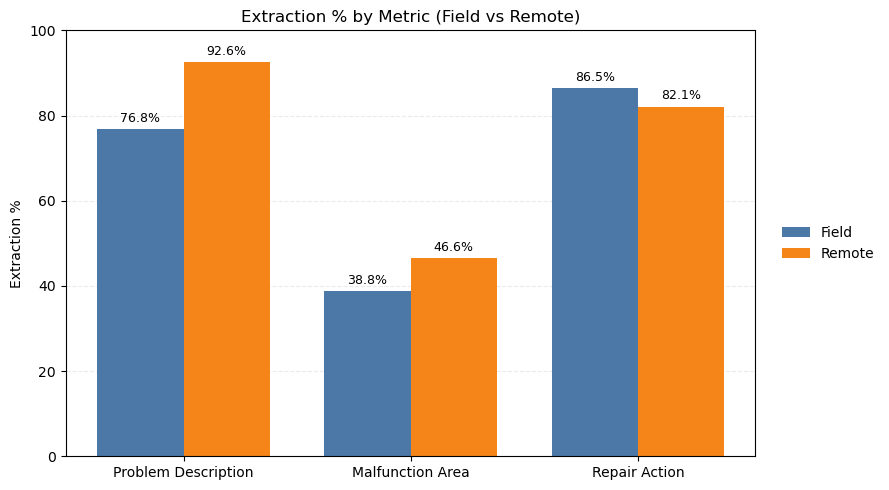

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics you want to compare
metrics = [
    "problem_description",
    "malfunction_area",
    "repair_action",
]

field_cols  = [f"extracted_{m}_field"  for m in metrics]
remote_cols = [f"extracted_{m}_remote" for m in metrics]

# Denominators (eligible rows)
field_mask  = df["field_remarks"].notna()
remote_mask = df["remote_remarks"].notna()
field_den   = field_mask.sum()
remote_den  = remote_mask.sum()

# Percentages
field_pct = [(df.loc[field_mask,  c].notna().sum() / field_den  * 100) if field_den  else 0 for c in field_cols]
remote_pct = [(df.loc[remote_mask, c].notna().sum() / remote_den * 100) if remote_den else 0 for c in remote_cols]

# Plot (grouped bars)
x = np.arange(len(metrics))
w = 0.38

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - w/2, field_pct,  width=w, color="#4C78A8", label="Field")
ax.bar(x + w/2, remote_pct, width=w, color="#F58518", label="Remote")

ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", " ").title() for m in metrics])
ax.set_ylabel("Extraction %")
ax.set_ylim(0, 100)
ax.set_title("Extraction % by Metric (Field vs Remote)")
ax.yaxis.grid(True, linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

# Value labels on top of bars
for i, v in enumerate(field_pct):
    ax.text(x[i] - w/2, v + 1, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
for i, v in enumerate(remote_pct):
    ax.text(x[i] + w/2, v + 1, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.tight_layout()
plt.show()

In [29]:
sample = df[df["extracted_problem_description_field"].notna()].iloc[0]
print("Problem:", sample["extracted_problem_description_field"])
print("Repair:", sample["extracted_repair_action_field"])
print("Malfunction:", sample["extracted_malfunction_area_field"])

Problem: Customer states there is error Scan Abort in message center and the device will not scan,  Customer has power cycled system at host pc and at the breakers,  No PRS connection, Remote password is not set,
Repair: nan
Malfunction: nan


In [30]:
mask = df["extracted_problem_description_field"].isna()
print(df[mask]["diagnostic_text"].notna().sum())

100


In [31]:
mask = (
    df["extracted_problem_description_field"].isna() &
    df["diagnostic_text"].notna()
)
print(df[mask].iloc[0]["diagnostic_text"][:300])

In [32]:
mask = (
    df["extracted_problem_description_field"].isna() &
    df["diagnostic_text"].notna()
)

# Check actual values
print(repr(df[mask].iloc[0]["diagnostic_text"]))
print(type(df[mask].iloc[0]["diagnostic_text"]))

''
<class 'str'>


Check failed extraction, orginal nan vs problem description None

In [33]:
mask = df["extracted_problem_description_remote"].isna()
print(f"Missing remote problem description: {mask.sum()}")
print(f"Of those, missing remote_remarks entirely: {df[mask]['remote_remarks'].isna().sum()}")

Missing remote problem description: 1792
Of those, missing remote_remarks entirely: 878


In [34]:
# rows that have remote_remarks but failed extraction
mask_failed = (
    df["extracted_problem_description_remote"].isna() & 
    df["remote_remarks"].notna()
)

# check country distribution of failures
print(df[mask_failed]["country"].value_counts().head(10))

# look at a raw example
print(df[mask_failed].iloc[0]["remote_remarks_en"][:500])

country
United States         211
United Kingdom        133
Russian Federation    121
Brazil                 40
Egypt                  40
Netherlands            36
Spain                  31
China                  31
Indirect Countries     25
Poland                 19
Name: count, dtype: int64[pyarrow]
*** T2 Activities [2025-06-16 08:06:50]
Troubleshooting Action: ????????? ????-????? ???????, 

??? ?????????? ????????? ??? ?????????? ??? 4? ??????????, 

???? ?????????? ??????????? ??? ?????? ??????? ????? ??????: 

1) FLUKE-435 Power Quality Analyzer,435/001 2654779 4000435001 
2) ?????????? ????????????? ??-20/1, ? ???????? ? ????????? ???? ????? 20/1 - 2136, 20/2 - 0744 
3) TC025 - Earth bonding tester Â 452298038072[3] 
??? TC378 452298038073 EARTH BONDING TESTER Gossen Secutest SIII+(+


In [35]:
# Sample 5 rows per country from top 10 countries
top_countries = df["country"].value_counts().head(10).index

for country in top_countries:
    sample = df[df["country"] == country]["extracted_problem_description_remote"].dropna().head(5)
    print(f"\n=== {country} ===")
    for text in sample:
        print(f"  → {text[:150]}")


=== United States ===
  → Customer states there is error Scan Abort in message center and the device will not scan,  Customer has power cycled system at host pc and at the brea
  → The chiller is down and is not powering back on- Ongoing issue
  → Biomed had question on vertical actuator on the table that is down,
  → The unit will not run after power surge
  → Both UPS's show battery low and system will not come up,

=== India ===
  → Reconstructor aborted after internal error
  → Workstation system is not switching On
  → Compressor Helium return gas line  leakage
  → Problem description by engineer : 
NotConfigured	Chain: - Orig: ConnQBC,BODY_QUAD,,
  → Table up and down movement not happening

=== Germany ===
  → mit Te Sven Lischer telefoniert,
Die StÃ¶rung wird bestÃ¤tigt,
  → Das gemeldete Problem wird bestÃ¤tigt
  → Problem description by engineer: 
Spoken to Mr. Frackiewicz +492421301490, The right monitor remains black,
  → Starker Druckabfall am GC Kreislauf, aktuell bei 0,

In [36]:
case = df[df["case_number"] == 125721564].iloc[0]

# Raw input
print("=== RAW REMOTE REMARKS ===")
print(case["remote_remarks_en"])

print("\n=== LAYER 1 — Intermediate columns ===")
print("t2_activities_text_remote:", repr(case["t2_activities_text_remote"]))
print("problem_description_text_remote:", repr(case["problem_description_text_remote"]))
print("resolution_text_remote:", repr(case["resolution_text_remote"]))

print("\n=== LAYER 2 — Extracted columns ===")
print("extracted_problem_description_remote:", repr(case["extracted_problem_description_remote"]))
print("extracted_troubleshooting_remote:", repr(case["extracted_troubleshooting_remote"]))
print("extracted_repair_action_remote:", repr(case["extracted_repair_action_remote"]))

=== RAW REMOTE REMARKS ===
*** T2 Activities [2025-06-30 00:20:52]
Problem Description: ?????
Magnet
??????????????
????
??????????
?
Troubleshooting Action: ??????????
NA
??????????
????????
PRS TR???
??
Repair Action: T2 ?????????
?????????????????
T2 ????12NC????
NA
???????
?
Case Level
H

=== LAYER 1 — Intermediate columns ===
t2_activities_text_remote: 'Problem Description: ?????\nMagnet\n??????????????\n????\n??????????\n?\nTroubleshooting Action: ??????????\nNA\n??????????\n????????\nPRS TR???\n??\nRepair Action: T2 ?????????\n?????????????????\nT2 ????12NC????\nNA\n???????\n?\nCase Level\nH'
problem_description_text_remote: nan
resolution_text_remote: nan

=== LAYER 2 — Extracted columns ===
extracted_problem_description_remote: '?????\nMagnet'
extracted_troubleshooting_remote: '??????????'
extracted_repair_action_remote: 'T2 ?????????\n?????????????????\nT2 ????12NC????\nNA\n???????\n?\nCase Level\nH'


In [37]:
import pandas as pd
from docx import Document
from docx.shared import Pt, RGBColor, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH

# --- Config ---
PARQUET_PATH = "data/processed/cfr_savings_processed.parquet"
OUTPUT_PATH  = "data/extraction_quality_check.docx"
TOP_N_COUNTRIES = 10
SAMPLES_PER_COUNTRY = 5

LAYER1_COLS = [
    "t2_activities_text_remote",
    "onems_internal_text_remote",
    "problem_description_text_remote",
    "diagnostic_text_remote",
    "resolution_text_remote",
    "internal_comments_text_remote",
    "external_remarks_text_remote",
]

LAYER2_COLS = [
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
]

# --- Load ---
df = pd.read_parquet(PARQUET_PATH)
top_countries = df["country"].value_counts().head(TOP_N_COUNTRIES).index.tolist()

# --- Helpers ---
def safe_str(val):
    if pd.isna(val) or val is None:
        return "[ EMPTY ]"
    s = str(val).strip()
    return s if s else "[ EMPTY ]"

def add_heading(doc, text, level=1, color=None):
    p = doc.add_heading(text, level=level)
    if color:
        for run in p.runs:
            run.font.color.rgb = RGBColor(*color)
    return p

def add_label_value(doc, label, value, label_color=(31, 56, 100), value_color=None):
    p = doc.add_paragraph()
    run_label = p.add_run(f"{label}: ")
    run_label.bold = True
    run_label.font.size = Pt(9)
    run_label.font.color.rgb = RGBColor(*label_color)
    run_value = p.add_run(value[:800] if len(value) > 800 else value)
    run_value.font.size = Pt(9)
    if value_color:
        run_value.font.color.rgb = RGBColor(*value_color)
    p.paragraph_format.space_after = Pt(2)

def add_divider(doc):
    p = doc.add_paragraph()
    p.paragraph_format.space_before = Pt(4)
    p.paragraph_format.space_after = Pt(4)
    run = p.add_run("─" * 80)
    run.font.size = Pt(8)
    run.font.color.rgb = RGBColor(180, 180, 180)

# --- Build document ---
doc = Document()

# Page margins
for section in doc.sections:
    section.top_margin    = Inches(0.8)
    section.bottom_margin = Inches(0.8)
    section.left_margin   = Inches(0.9)
    section.right_margin  = Inches(0.9)

# Title
title = doc.add_heading("Extraction Quality Check — Remote Remarks", level=0)
for run in title.runs:
    run.font.size = Pt(16)
    run.font.color.rgb = RGBColor(31, 56, 100)

doc.add_paragraph(
    f"Top {TOP_N_COUNTRIES} countries by volume | {SAMPLES_PER_COUNTRY} cases each | "
    f"Layer 1 intermediate + Layer 2 extracted columns"
).runs[0].font.size = Pt(9)

doc.add_paragraph()

# --- Loop countries ---
for country in top_countries:
    country_df = df[df["country"] == country].dropna(subset=["remote_remarks_en"])
    sample = country_df.sample(
        n=min(SAMPLES_PER_COUNTRY, len(country_df)), 
        random_state=42
    )
    
    add_heading(doc, f"{country}  ({len(country_df)} rows with remote_remarks_en)", 
                level=1, color=(46, 117, 182))
    
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        add_heading(doc, f"Case {row['case_number']}  —  Example {i} of {SAMPLES_PER_COUNTRY}", 
                    level=2, color=(68, 114, 196))
        
        # Raw
        add_label_value(doc, "RAW remote_remarks_en", 
                       safe_str(row.get("remote_remarks_en")),
                       label_color=(150, 0, 0))
        
        doc.add_paragraph()
        p = doc.add_paragraph()
        run = p.add_run("LAYER 1 — Intermediate columns")
        run.bold = True
        run.font.size = Pt(9)
        run.font.color.rgb = RGBColor(0, 112, 0)
        
        for col in LAYER1_COLS:
            val = safe_str(row.get(col))
            if val != "[ EMPTY ]":
                add_label_value(doc, col, val, label_color=(0, 112, 0))
        
        doc.add_paragraph()
        p = doc.add_paragraph()
        run = p.add_run("LAYER 2 — Extracted columns")
        run.bold = True
        run.font.size = Pt(9)
        run.font.color.rgb = RGBColor(130, 0, 130)
        
        for col in LAYER2_COLS:
            val = safe_str(row.get(col))
            color = (130, 0, 130) if val != "[ EMPTY ]" else (150, 150, 150)
            add_label_value(doc, col, val, label_color=color)
        
        add_divider(doc)
    
    doc.add_page_break()

# --- Save ---
doc.save(OUTPUT_PATH)
print(f"Saved to {OUTPUT_PATH}")

Saved to data/extraction_quality_check.docx


In [38]:
import pandas as pd

df = pd.read_parquet("data/processed/cfr_savings_processed.parquet")

boilerplate_markers = [
    "Information to support the complaint handling process",
    "Customer Function/Role",
    "How was the device being used",
    "Expected and actual behavior",
    "User Impact:",
    "Patient Impact:",
    "Current Software Version",
]

for col in ["extracted_problem_description_remote", "extracted_problem_description_field"]:
    non_null = df[col].notna().sum()
    
    # correct: flag each document ONCE if it contains ANY marker
    contaminated_mask = pd.Series(False, index=df.index)
    for marker in boilerplate_markers:
        contaminated_mask = contaminated_mask | df[col].fillna("").str.contains(marker, case=False)
    
    contaminated = contaminated_mask.sum()
    clean = non_null - contaminated
    
    print(f"{col}:")
    print(f"  Total non-null: {non_null}")
    print(f"  Clean: {clean} ({100*clean/max(non_null,1):.1f}%)")
    print(f"  Contains boilerplate: {contaminated} ({100*contaminated/max(non_null,1):.1f}%)")
    print()

extracted_problem_description_remote:
  Total non-null: 11402
  Clean: 11402 (100.0%)
  Contains boilerplate: 0 (0.0%)

extracted_problem_description_field:
  Total non-null: 5861
  Clean: 5861 (100.0%)
  Contains boilerplate: 0 (0.0%)



Checking Label Extraction form LAM Market

In [39]:
nam = df[df["market"] == "NAM"]
print(f"NAM cases: {len(nam)}\n")

for col in ["nam_main_category", "nam_sub_category", "nam_event_type"]:
    print(f"── {col} ──")
    print(f"  Non-null: {nam[col].notna().sum()} / {len(nam)}")
    print(nam[col].value_counts().to_string())
    print()

NAM cases: 2310

── nam_main_category ──
  Non-null: 1733 / 2310
nam_main_category
data_acquisition        226
patient_support         222
consoles                191
gradient_amp            186
cooling_system          161
software                141
rf_amp                  119
chiller                 116
coil                    106
environmental            86
magnet                   80
reconstructor            36
image_quality            17
other                    14
third_party_item         11
physiology                6
system_related_parts      5
clinical_mr               4
patient_ventilation       4
shim_cabinet              1
ambient_exp               1

── nam_sub_category ──
  Non-null: 1727 / 2310
nam_sub_category
axis_module                     121
lcc                             120
spectrometer                    120
rf_amp                           97
other                            90
dstream                          79
no_contract                      75
mon_mouse_ke

In [40]:
for event in ["corrective_maintenance_dispatch", "corrective_maintenance_remote_fix"]:
    subset = nam[nam["nam_event_type"] == event]
    both_nan = subset["field_remarks"].isna() & subset["parts_consumed_list"].isna()
    print(f"── {event} ({len(subset)} cases) ──")
    print(f"  field_remarks NaN AND parts_consumed_list NaN: {both_nan.sum()} ({100*both_nan.mean():.1f}%)")
    print(f"  field_remarks NaN only:       {subset['field_remarks'].isna().sum()}")
    print(f"  parts_consumed_list NaN only: {subset['parts_consumed_list'].isna().sum()}")
    print()

── corrective_maintenance_dispatch (1060 cases) ──
  field_remarks NaN AND parts_consumed_list NaN: 29 (2.7%)
  field_remarks NaN only:       29
  parts_consumed_list NaN only: 589

── corrective_maintenance_remote_fix (669 cases) ──
  field_remarks NaN AND parts_consumed_list NaN: 632 (94.5%)
  field_remarks NaN only:       637
  parts_consumed_list NaN only: 659



In [43]:
from sentence_transformers import SentenceTransformer
from src.classification.taxonomy import load_taxonomy, format_taxonomy_for_prompt
from src.classification.retriever import build_index, retrieve_examples
from src.classification.evaluation import split_labeled_data, evaluate_retrieval
from src.classification.retriever import retrieve_batch

# load
embedding_model = SentenceTransformer("models/bge-base-en-v1.5")
taxonomy = load_taxonomy("data/raw/nam_label.xlsx")

# filter to labeled cases with text
nam_labeled = df[
    df["nam_main_category"].notna() & 
    df["extracted_problem_description_remote"].notna()
].copy()
print(f"Labeled cases with text: {len(nam_labeled)}")

# split: 80% for index, 20% for testing
index_df, test_df = split_labeled_data(nam_labeled, test_size=0.2)

# build index from the 80%
index = build_index(
    index_df,
    text_col="extracted_problem_description_remote",
    label_cols=["nam_main_category", "nam_sub_category"],
    embedding_model=embedding_model,
)

# retrieve examples for all test cases
test_texts = test_df["extracted_problem_description_remote"].tolist()
all_examples = retrieve_batch(test_texts, index, embedding_model, n=5)

# evaluate retrieval quality
retrieval_results = evaluate_retrieval(
    test_df, all_examples, 
    "extracted_problem_description_remote", 
    "nam_main_category",
)
print(f"\nMajority vote accuracy: {retrieval_results['majority_accuracy']:.1%}")
print(f"Any correct in top-5:   {retrieval_results['any_correct_rate']:.1%}")
print(f"Avg top-1 similarity:   {retrieval_results['avg_top1_similarity']:.3f}")

'[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1016)' thrown while requesting HEAD https://huggingface.co/models/bge-base-en-v1.5/resolve/main/./README.md
Retrying in 1s [Retry 1/5].
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 38301.51it/s]
BertModel LOAD REPORT from: models/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Labeled cases with text: 1607
  Split: 1285 index / 322 test (80% / 20%)
  Embedding 1282 labeled cases...


Batches: 100%|██████████| 41/41 [01:05<00:00,  1.61s/it]


  Index built: 1282 cases, 768 dimensions


Batches: 100%|██████████| 11/11 [00:20<00:00,  1.91s/it]


Majority vote accuracy: 62.7%
Any correct in top-5:   79.2%
Avg top-1 similarity:   0.851


In [46]:
# look at 5 random test cases and their retrieved examples
import random
random.seed(43)
sample_indices = random.sample(range(len(test_texts)), 5)

for i in sample_indices:
    true_main = test_df.iloc[i]["nam_main_category"]
    true_sub = test_df.iloc[i]["nam_sub_category"]
    print(f"\n{'='*70}")
    print(f"TEST CASE: {test_texts[i][:150]}")
    print(f"TRUE LABEL: {true_main} / {true_sub}")
    print(f"RETRIEVED:")
    for j, ex in enumerate(all_examples[i]):
        ex_main = ex["labels"]["nam_main_category"]
        ex_sub = ex["labels"]["nam_sub_category"]
        match = "✓" if ex_main == true_main else "✗"
        print(f"  {match} [{ex['similarity']:.3f}] {ex_main}/{ex_sub}: {ex['text'][:100]}")


TEST CASE: Table top jamming up coming out of the bore
TRUE LABEL: patient_support / covers
RETRIEVED:
  ✓ [0.863] patient_support/horz_drive_unit: Table is stuck coming out of bore and hits hard stop
  ✓ [0.805] patient_support/table_lockup: table will not move in to bore
  ✓ [0.802] patient_support/horz_drive_unit: tabletop movements are jammed and noise comes from table if movement is attempted
  ✓ [0.790] patient_support/covers: Mid section table covers jammed up
  ✓ [0.782] patient_support/covers: Table gets stuck at the same point coming out

TEST CASE: Unable to bring system back up, no video input on monitor after storm occurred overnight,
TRUE LABEL: consoles / mon_mouse_key
RETRIEVED:
  ✓ [0.823] consoles/host_computer: System down. No video on monitor
  ✓ [0.787] consoles/mon_mouse_key: Monitor is black, no display on screen. Unable to bring up the system.
  ✓ [0.782] consoles/host_computer: No input signal at the monitor this morning
  ✓ [0.779] consoles/host_computer: mon

In [45]:
from collections import Counter

# Full confusion analysis across all 322 test cases
true_labels = test_df["nam_main_category"].tolist()
confusion_pairs = []

for i, (true_label, examples) in enumerate(zip(true_labels, all_examples)):
    retrieved_labels = [ex["labels"]["nam_main_category"] for ex in examples]
    majority_label = Counter(retrieved_labels).most_common(1)[0][0]
    
    if majority_label != true_label:
        confusion_pairs.append((true_label, majority_label))

# count how often each confusion pair occurs
pair_counts = Counter(confusion_pairs)
print(f"Total mismatches: {len(confusion_pairs)} / {len(true_labels)}\n")
print(f"{'True Label':<25} {'Retrieved As':<25} {'Count':>5}")
print("-" * 58)
for (true, pred), count in pair_counts.most_common(20):
    print(f"{true:<25} {pred:<25} {count:>5}")

# also show per-category retrieval accuracy
print(f"\n{'Category':<25} {'Total':>6} {'Correct':>8} {'Accuracy':>9}")
print("-" * 52)
cat_stats = {}
for i, (true_label, examples) in enumerate(zip(true_labels, all_examples)):
    retrieved_labels = [ex["labels"]["nam_main_category"] for ex in examples]
    majority_label = Counter(retrieved_labels).most_common(1)[0][0]
    
    if true_label not in cat_stats:
        cat_stats[true_label] = {"total": 0, "correct": 0}
    cat_stats[true_label]["total"] += 1
    if majority_label == true_label:
        cat_stats[true_label]["correct"] += 1

for cat, stats in sorted(cat_stats.items(), key=lambda x: x[1]["correct"]/max(x[1]["total"],1)):
    acc = stats["correct"] / stats["total"]
    print(f"{cat:<25} {stats['total']:>6} {stats['correct']:>8} {acc:>8.1%}")


Total mismatches: 120 / 322

True Label                Retrieved As              Count
----------------------------------------------------------
cooling_system            chiller                       7
consoles                  data_acquisition              7
software                  data_acquisition              6
data_acquisition          patient_support               5
rf_amp                    gradient_amp                  4
data_acquisition          software                      4
environmental             chiller                       3
gradient_amp              data_acquisition              3
cooling_system            magnet                        2
reconstructor             data_acquisition              2
patient_support           coil                          2
coil                      data_acquisition              2
physiology                consoles                      2
data_acquisition          rf_amp                        2
environmental             cooling_system  